In [3]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split

# Load datasets
files = {
    # Profile / user-level finance
    "finance_expenses": "../data/profile/personal_finance_expenses.csv",
    "finance_tracker": "../data/profile/personal_finance_tracker_dataset.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

# Show quick info
for name, df in dfs.items():
    print(f"\n===== {name.upper()} =====")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:\n", df.isnull().sum())
    print(df.head(3))



===== FINANCE_EXPENSES =====
Shape: (20000, 27)
Columns: ['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']
Missing values:
 Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out     

In [4]:
# Explicit references
df_exp = dfs["finance_expenses"]   # regression only
df_trk = dfs["finance_tracker"]    # classification + regression

In [5]:
# Target
y_cls = df_trk["savings_goal_met"]

# Candidate numeric features
num_cols = [
    "monthly_income", "monthly_expense_total", "savings_rate", "budget_goal",
    "credit_score", "debt_to_income_ratio", "loan_payment", "investment_amount",
    "subscription_services", "emergency_fund", "transaction_count",
    "discretionary_spending", "essential_spending", "rent_or_mortgage",
    "financial_advice_score"
]

# Check which are missing (just to be safe)
missing = [c for c in num_cols if c not in df_trk.columns]
print("Missing numeric features:", missing)

# Start X with numeric columns
X_cls = df_trk[num_cols].copy()
X_cls.head()


Missing numeric features: []


,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,discretionary_spending,essential_spending,rent_or_mortgage,financial_advice_score
0,3119.58,3212.07,0.38,3676.11,721.0,0.56,125.77,689.22,3,510.58,68,857.55,1910.85,1501.65,8.3
1,3262.44,3732.81,0.10,2607.17,670.0,0.42,454.19,360.34,4,1154.41,41,534.51,3165.20,1603.17,22.6
2,2931.20,3335.58,0.15,3004.14,691.0,0.24,971.82,0.00,5,1433.02,90,353.67,1504.56,1097.82,58.8
3,3506.79,2327.59,0.17,3346.97,717.0,0.16,482.76,182.06,5,227.37,94,594.08,1450.72,1155.64,74.5
4,4606.87,2182.58,0.34,2670.09,795.0,0.25,263.74,342.78,9,589.81,73,556.86,1000.00,1170.86,38.7


In [6]:
# Categorical features to encode
cat_cols = ["financial_scenario", "income_type", "category",
            "cash_flow_status", "financial_stress_level"]

# keep only those that actually exist in df_trk
cat_cols_present = [c for c in cat_cols if c in df_trk.columns]
print("Categorical columns available:", cat_cols_present)

# One-hot encode and add to X
X_cls = pd.concat([X_cls, pd.get_dummies(df_trk[cat_cols_present], drop_first=False)], axis=1)

print("X_cls shape after encoding:", X_cls.shape)
X_cls.head()


Categorical columns available: ['financial_scenario', 'income_type', 'category', 'cash_flow_status', 'financial_stress_level']
X_cls shape after encoding: (3000, 37)


,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,...,category_Investments,category_Rent,category_Transportation,category_Utilities,cash_flow_status_Negative,cash_flow_status_Neutral,cash_flow_status_Positive,financial_stress_level_High,financial_stress_level_Low,financial_stress_level_Medium
0,3119.58,3212.07,0.38,3676.11,721.0,0.56,125.77,689.22,3,510.58,...,True,False,False,False,False,False,True,False,True,False
1,3262.44,3732.81,0.10,2607.17,670.0,0.42,454.19,360.34,4,1154.41,...,True,False,False,False,False,False,True,False,True,False
2,2931.20,3335.58,0.15,3004.14,691.0,0.24,971.82,0.00,5,1433.02,...,False,False,False,False,False,False,True,False,True,False
3,3506.79,2327.59,0.17,3346.97,717.0,0.16,482.76,182.06,5,227.37,...,False,False,False,False,False,False,True,False,True,False
4,4606.87,2182.58,0.34,2670.09,795.0,0.25,263.74,342.78,9,589.81,...,False,False,False,True,True,False,False,True,False,False


In [7]:
# Train/test split (stratify ensures class balance)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("Training set:", Xc_train.shape, yc_train.shape)
print("Test set:", Xc_test.shape, yc_test.shape)


Training set: (2400, 37) (2400,)
Test set: (600, 37) (600,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

logit = LogisticRegression(max_iter=2000, solver='liblinear')
logit.fit(Xc_train, yc_train)

yc_pred  = logit.predict(Xc_test)
yc_proba = logit.predict_proba(Xc_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred))
print("\nClassification Report:\n", classification_report(yc_test, yc_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(yc_test, yc_proba), 4))


Confusion Matrix:
 [[544   1]
 [  1  54]]

Classification Report:
               precision    recall  f1-score   support

           0      0.998     0.998     0.998       545
           1      0.982     0.982     0.982        55

    accuracy                          0.997       600
   macro avg      0.990     0.990     0.990       600
weighted avg      0.997     0.997     0.997       600

ROC-AUC: 1.0


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# RandomForest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced_subsample"  # handles any imbalance
)
rf.fit(Xc_train, yc_train)

# Predictions
rf_pred  = rf.predict(Xc_test)
rf_proba = rf.predict_proba(Xc_test)[:, 1]

# Metrics
print("Confusion Matrix:\n", confusion_matrix(yc_test, rf_pred))
print("\nClassification Report:\n", classification_report(yc_test, rf_pred, digits=3))
print("ROC-AUC:", round(roc_auc_score(yc_test, rf_proba), 4))


Confusion Matrix:
 [[545   0]
 [ 34  21]]

Classification Report:
               precision    recall  f1-score   support

           0      0.941     1.000     0.970       545
           1      1.000     0.382     0.553        55

    accuracy                          0.943       600
   macro avg      0.971     0.691     0.761       600
weighted avg      0.947     0.943     0.932       600

ROC-AUC: 0.9914


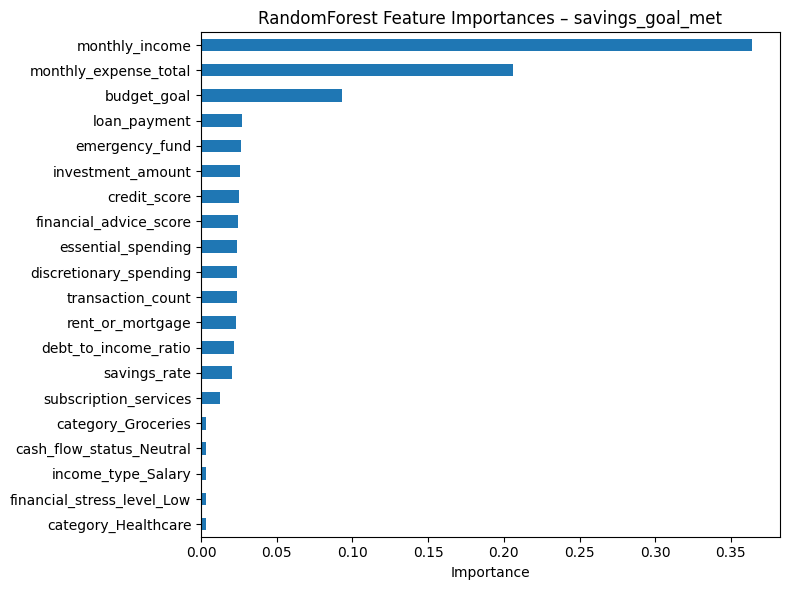

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=Xc_train.columns)

# Sort and take top 20
importances = importances.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.title("RandomForest Feature Importances – savings_goal_met")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [11]:
# Save importances to CSV
importances.to_csv("../models/savings_goal_met_feature_importances.csv")
print("✅ Saved feature importances to ../models/savings_goal_met_feature_importances.csv")

✅ Saved feature importances to ../models/savings_goal_met_feature_importances.csv


In [12]:
import joblib, os
os.makedirs("../models", exist_ok=True)

# Save Logistic Regression model (savings_goal_met)
joblib.dump(logit, "../models/savings_goal_met_clf.pkl")
joblib.dump(X_cls.columns.tolist(), "../models/savings_goal_met_columns.pkl")

print("✅ Saved Logistic Regression model and columns.")


✅ Saved Logistic Regression model and columns.


In [13]:
# Financial Stress Level Classification.

# Target: multiclass (Low / Medium / High)
y_stress = df_trk["financial_stress_level"]

# Reuse the same feature matrix you built for savings_goal_met
X_stress = X_cls.copy()

print(y_stress.value_counts())
X_stress.shape


financial_stress_level
Low       1521
Medium     886
High       593
Name: count, dtype: int64


(3000, 37)

In [14]:
from sklearn.model_selection import train_test_split

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_stress, y_stress, test_size=0.2, random_state=42, stratify=y_stress
)

print("Train:", Xs_train.shape, ys_train.shape)
print("Test :", Xs_test.shape, ys_test.shape)


Train: (2400, 37) (2400,)
Test : (600, 37) (600,)


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# numeric columns you used earlier (keep only those present)
num_cols = [
    "monthly_income","monthly_expense_total","savings_rate","budget_goal",
    "credit_score","debt_to_income_ratio","loan_payment","investment_amount",
    "subscription_services","emergency_fund","transaction_count",
    "discretionary_spending","essential_spending","rent_or_mortgage",
    "financial_advice_score"
]
num_cols = [c for c in num_cols if c in Xs_train.columns]

# scale numeric, pass through the rest (one-hot categoricals)
pre = ColumnTransformer(
    transformers=[("scale_num", StandardScaler(), num_cols)],
    remainder="passthrough"
)

# multinomial is now default; bump max_iter; optionally balance classes
logit_mc = make_pipeline(
    pre,
    LogisticRegression(solver="lbfgs", max_iter=5000, class_weight=None)
)

logit_mc.fit(Xs_train, ys_train)
ys_pred = logit_mc.predict(Xs_test)

print("Confusion Matrix:\n", confusion_matrix(ys_test, ys_pred, labels=["Low","Medium","High"]))
print("\nClassification Report:\n", classification_report(ys_test, ys_pred, digits=3))
print("Accuracy:", round(accuracy_score(ys_test, ys_pred), 4))


Confusion Matrix:
 [[304   0   0]
 [  0 177   0]
 [  0   0 119]]

Classification Report:
               precision    recall  f1-score   support

        High      1.000     1.000     1.000       119
         Low      1.000     1.000     1.000       304
      Medium      1.000     1.000     1.000       177

    accuracy                          1.000       600
   macro avg      1.000     1.000     1.000       600
weighted avg      1.000     1.000     1.000       600

Accuracy: 1.0


In [21]:
import joblib, os
os.makedirs("../models", exist_ok=True)

best_mc = logit_mc  # or rf_mc if it performs better for you
joblib.dump(best_mc, "../models/financial_stress_level_clf.pkl")
joblib.dump(X_stress.columns.tolist(), "../models/financial_stress_level_columns.pkl")

print("✅ Saved multiclass classifier and columns.")


✅ Saved multiclass classifier and columns.
